# TSP-50 demo: AM greedy vs AM sampling vs MCTS vs exact solver

End-to-end comparison of four solving methods on a single TSP-50 instance:

1. **AM greedy** — argmax decoding from the trained Attention Model.
2. **AM sampling** — best-of-K stochastic decoding (paper-style test-time search).
3. **MCTS** — AlphaGo-Zero-style tree search using the AM as policy + greedy rollouts as leaf eval (Stage 2 canonical config).
4. **Exact** — Gurobi MIP with lazy subtour elimination; falls back to LKH (via `elkai`) when Gurobi is not available. LKH is near-optimal (typically <0.001%% gap on TSP-50).

Run with the `AM_AlphaGoZero` conda env active. CPU is fine for a single instance — expect a few seconds total at the default settings.

In [41]:
import os, sys, time
import numpy as np
import torch
import matplotlib.pyplot as plt

# Make `src/` importable regardless of where the notebook is launched from.
_cwd = os.path.abspath(os.getcwd())
REPO_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd
SRC = os.path.join(REPO_ROOT, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)
print('Repo root :', REPO_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device    :', device)

Repo root : c:\Users\Jun18\Desktop\AM_ALPHAGOZERO
Device    : cuda


## Configuration

Adjust `CHECKPOINT_PATH` if your TSP-50 model lives elsewhere. The default points at the Stage 1 canonical run with the value head trained (`stage1_tsp50_with_value_*`).

In [42]:
GRAPH_SIZE   = 50
SEED         = 1234
INSTANCE_IDX = 0       # which instance from the seeded dataset to demo
SAMPLING_K   = 1280    # AM-paper sampling width
MCTS_K       = 128     # MCTS simulations per tour-step (raise for tighter gap, slower)

CHECKPOINT_PATH = os.path.join(
    REPO_ROOT, 'outputs', 'tsp_50',
    'stage1_tsp50_with_value_20260424T032357', 'epoch-99.pt',
)

## Generate one TSP-50 instance

Instance shape: (50, 2)


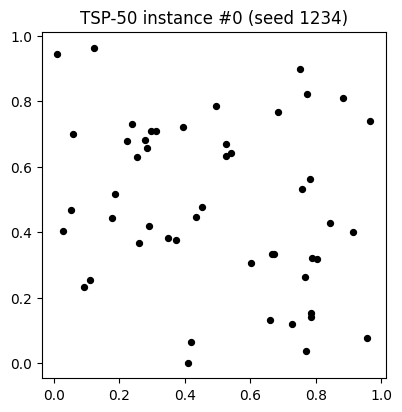

In [43]:
from am_baseline.problem.tsp import TSP

torch.manual_seed(SEED)
np.random.seed(SEED)

dataset = TSP.make_dataset(size=GRAPH_SIZE, num_samples=max(INSTANCE_IDX + 1, 16))
inst    = dataset[INSTANCE_IDX]              # (N, 2)
inst_b  = inst.unsqueeze(0).to(device)       # (1, N, 2) batched form expected by the model
print('Instance shape:', tuple(inst.shape))

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(inst[:, 0], inst[:, 1], c='black', s=18)
ax.set_aspect('equal')
ax.set_title(f'TSP-{GRAPH_SIZE} instance #{INSTANCE_IDX} (seed {SEED})')
plt.show()

## Load the trained AM (with value head)

In [44]:
from am_baseline.utils.misc import load_model

if not os.path.isfile(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Checkpoint not found:\n  {CHECKPOINT_PATH}\n\n"
        "Edit CHECKPOINT_PATH above to point at your TSP-50 .pt file. "
        "To train one, see src/scripts/train.py with --graph_size 50 and --value_enabled. "
        "The Stage 1 canonical TSP-50 run is referenced in _progress/stage1_progress.md."
    )

model, model_args = load_model(CHECKPOINT_PATH)
model = model.to(device).eval()
print(f"Loaded AttentionModel for TSP-{model_args['graph_size']}")
print(f"value_head present: {model.value_head is not None}")

Loaded AttentionModel for TSP-50
value_head present: True


## 1. AM greedy

In [45]:
model.set_decode_type('greedy')
t0 = time.time()
with torch.no_grad():
    cost_g, _, pi_g = model(inst_b, return_pi=True)
t_greedy   = time.time() - t0
tour_greedy = pi_g[0].cpu().numpy()
cost_greedy = float(cost_g[0].item())
print(f'AM greedy: cost = {cost_greedy:.4f}   time = {t_greedy*1000:.1f} ms')

AM greedy: cost = 5.5140   time = 68.3 ms


## 2. AM sampling (best of K)

In [46]:
torch.manual_seed(SEED)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

model.set_decode_type('sampling')
t0 = time.time()
with torch.no_grad():
    pi_s, cost_s = model.sample_many(inst_b, batch_rep=SAMPLING_K, iter_rep=1)
t_sampling   = time.time() - t0
tour_sampling = pi_s[0].cpu().numpy()
cost_sampling = float(cost_s[0].item())
print(f'AM sampling K={SAMPLING_K}: cost = {cost_sampling:.4f}   time = {t_sampling*1000:.1f} ms')

AM sampling K=1280: cost = 5.4029   time = 363.5 ms


## 3. MCTS (AlphaGo-Zero-style on AM + value roll out)

Stage 2 canonical config: `c_puct=0.05`, `leaf_eval='rollout'`, `value_norm='bl'`, `fpu_mode='running_q'`, `tree_reuse=True`. Uses the greedy cost from step 1 as the per-instance baseline normalizer (`bl_val`).

In [47]:
from am_baseline.search import MCTSConfig, MCTSSolver

cfg = MCTSConfig(
    n_simulations=MCTS_K,
    c_puct=0.05,
    leaf_eval='rollout',
    value_norm='bl',
    fpu_mode='running_q',
    tree_reuse=True,
    seed=SEED,
)
solver = MCTSSolver(model, cfg, device=device)

t0 = time.time()
cost_m, tour_m = solver.solve_instance(inst_b, bl_val=cost_greedy)
t_mcts   = time.time() - t0
tour_mcts = tour_m.cpu().numpy()
cost_mcts = float(cost_m.item())
print(f'MCTS K={MCTS_K}: cost = {cost_mcts:.4f}   time = {t_mcts*1000:.1f} ms')
print(f'  fwd-pass mix: decode={solver.fwd_count_decode}  rollout={solver.fwd_count_rollout}  value={solver.fwd_count_value}')

MCTS K=128: cost = 5.4090   time = 13557.9 ms
  fwd-pass mix: decode=9803  rollout=9378  value=0


## 3b. MCTS — C++ backend (drop-in replacement)

Same canonical config as section 3, but with the tree walk in C++ via the pybind11 extension at `src/am_baseline/search/mcts_cpp/`. The AttentionModel forward boundary stays in Python/PyTorch; C++ owns the node/state/PUCT bookkeeping and calls a small Python evaluator for `decode_step` (and the value head when needed). Build the extension once with `pip install -e .` inside the conda env.

We use the **same `MCTSConfig` and `bl_val`** as the Python solver, so the search trajectory is identical — `CppMCTSSolver` is a drop-in replacement for `MCTSSolver`. Expect the same tour, the same `decode`/`rollout` forward-pass counts, but a substantially shorter wall-clock thanks to the C++ tree loop and an evaluator-side decoder cache.

In [48]:
from am_baseline.search import CppMCTSSolver, HAVE_CPP_MCTS

assert HAVE_CPP_MCTS, (
    "C++ MCTS extension is not built. From the repo root, with the AM_AlphaGoZero "
    "conda env active, run:  pip install -e .  (this compiles the pybind11 module)."
)

# Reuse the exact same cfg as section 3 so the two backends are directly comparable.
solver_cpp = CppMCTSSolver(model, cfg, device=device)

t0 = time.time()
cost_m_cpp, tour_m_cpp = solver_cpp.solve_instance(inst_b, bl_val=cost_greedy)
t_mcts_cpp   = time.time() - t0
tour_mcts_cpp = tour_m_cpp.cpu().numpy()
cost_mcts_cpp = float(cost_m_cpp.item())

print(f'MCTS-cpp K={MCTS_K}: cost = {cost_mcts_cpp:.4f}   time = {t_mcts_cpp*1000:.1f} ms')
print(f'  fwd-pass mix: decode={solver_cpp.fwd_count_decode}  rollout={solver_cpp.fwd_count_rollout}  value={solver_cpp.fwd_count_value}')
print(f'  decoder cache: hits={solver_cpp.eval_cache_hits}  misses={solver_cpp.eval_cache_misses}')

# Sanity check vs the Python backend from section 3.
same_tour = bool(np.array_equal(tour_mcts_cpp, tour_mcts))
cost_diff = abs(cost_mcts_cpp - cost_mcts)
speedup   = t_mcts / t_mcts_cpp if t_mcts_cpp > 0 else float('inf')
print(f'  vs Python MCTS: same tour = {same_tour}, |cost diff| = {cost_diff:.2e}, speedup = {speedup:.1f}x')

MCTS-cpp K=128: cost = 5.4090   time = 296.4 ms
  fwd-pass mix: decode=9803  rollout=9378  value=0
  decoder cache: hits=9545  misses=258
  vs Python MCTS: same tour = True, |cost diff| = 1.43e-06, speedup = 45.7x


## 4. Exact solver

Try Gurobi (true exact MIP). If unavailable, fall back to LKH via the `elkai` wrapper — near-optimal at n=50.

In [49]:
loc_list = inst.numpy().tolist()  # solve_gurobi expects list-of-lists
loc_arr  = inst.numpy()           # solve_lkh_elkai uses scipy.distance_matrix

exact_label = None
tour_exact  = None
cost_exact  = None
t_exact     = None

try:
    from scripts.eval_baselines import solve_gurobi
    t0 = time.time()
    cost_exact, tour_exact = solve_gurobi(loc_list)
    t_exact = time.time() - t0
    exact_label = 'Gurobi (exact)'
except Exception as e:
    print(f'Gurobi unavailable ({type(e).__name__}: {e}); falling back to LKH (elkai).')
    from scripts.eval_baselines import solve_lkh_elkai
    t0 = time.time()
    cost_exact, tour_exact = solve_lkh_elkai(loc_arr)
    t_exact = time.time() - t0
    exact_label = 'LKH (elkai, near-optimal)'

tour_exact = np.asarray(tour_exact)
cost_exact = float(cost_exact)
print(f'{exact_label}: cost = {cost_exact:.4f}   time = {t_exact*1000:.1f} ms')

Gurobi (exact): cost = 5.4029   time = 112.8 ms


## Comparison — table + tour visualizations

Gap is computed against the lowest cost among the four methods (so the best method always shows 0.000%%; usually that's the exact / LKH solver).

Method                                 Cost      Gap%        Time
----------------------------------------------------------------
AM greedy                            5.5140    2.056%      68.3ms
AM sampling K=1280                   5.4029    0.000%     363.5ms
MCTS-py  K=128                       5.4090    0.112%   13557.9ms
MCTS-cpp K=128                       5.4090    0.112%     296.4ms
Gurobi (exact)                       5.4029    0.000%     112.8ms


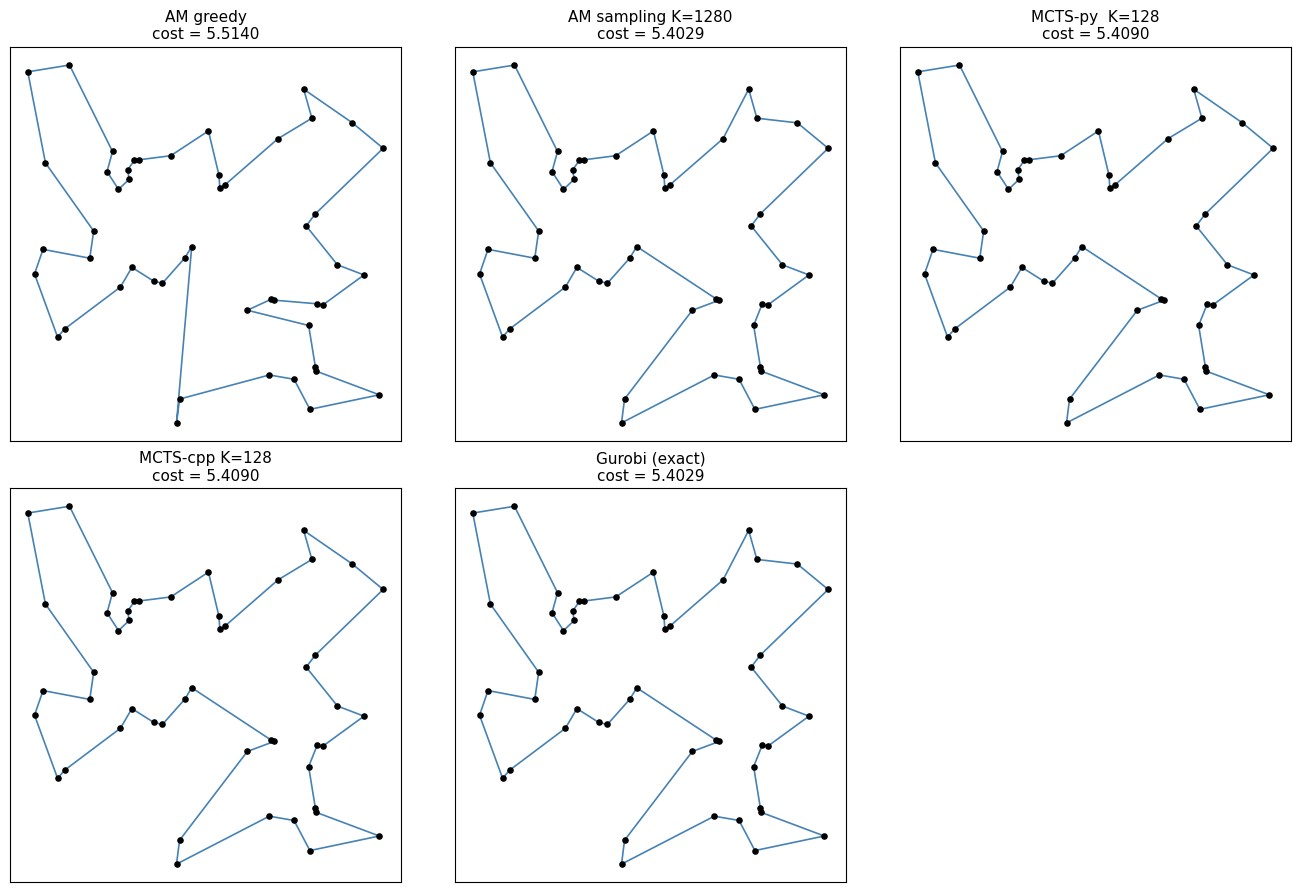

In [50]:
results = [
    ('AM greedy',                  cost_greedy,    tour_greedy,    t_greedy),
    (f'AM sampling K={SAMPLING_K}', cost_sampling,  tour_sampling,  t_sampling),
    (f'MCTS-py  K={MCTS_K}',        cost_mcts,      tour_mcts,      t_mcts),
    (f'MCTS-cpp K={MCTS_K}',        cost_mcts_cpp,  tour_mcts_cpp,  t_mcts_cpp),
    (exact_label,                  cost_exact,     tour_exact,     t_exact),
]

best = min(r[1] for r in results)
print(f'{"Method":<32}  {"Cost":>9}  {"Gap%":>8}  {"Time":>10}')
print('-' * 64)
for name, cost, _, elapsed in results:
    gap = (cost - best) / best * 100.0
    print(f'{name:<32}  {cost:>9.4f}  {gap:>7.3f}%  {elapsed*1000:>8.1f}ms')

def plot_tour(ax, coords, tour, title):
    pts = coords[np.append(tour, tour[0])]
    ax.plot(pts[:, 0], pts[:, 1], '-', color='steelblue', lw=1.2)
    ax.scatter(coords[:, 0], coords[:, 1], c='black', s=14, zorder=3)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

coords_np = inst.numpy()
n_panels  = len(results)
ncols     = 3 if n_panels > 4 else 2
nrows     = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes_flat = np.array(axes).reshape(-1)
for ax, (name, cost, tour, _) in zip(axes_flat, results):
    plot_tour(ax, coords_np, np.asarray(tour), f'{name}\ncost = {cost:.4f}')
for ax in axes_flat[len(results):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()